C:\Users\elisabethung\AppData\Local\Temp\ipykernel_27584\4223669598.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


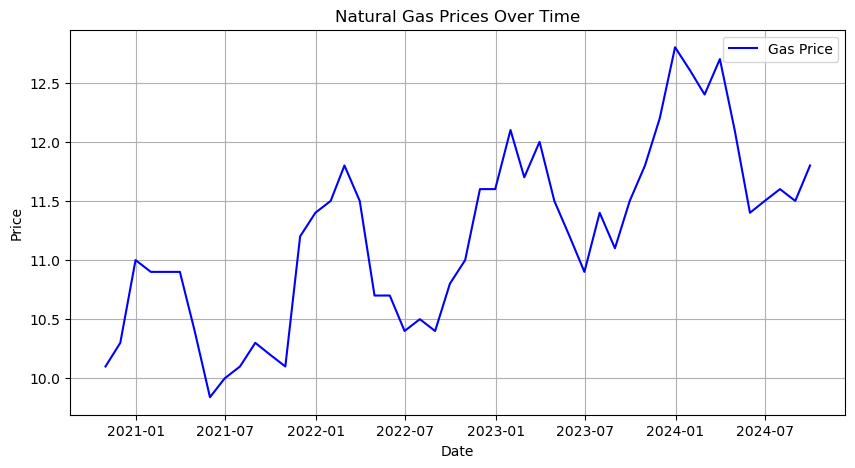

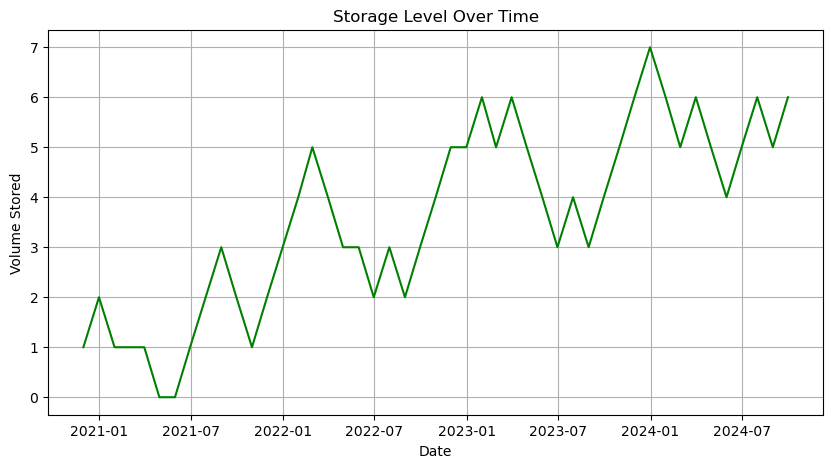

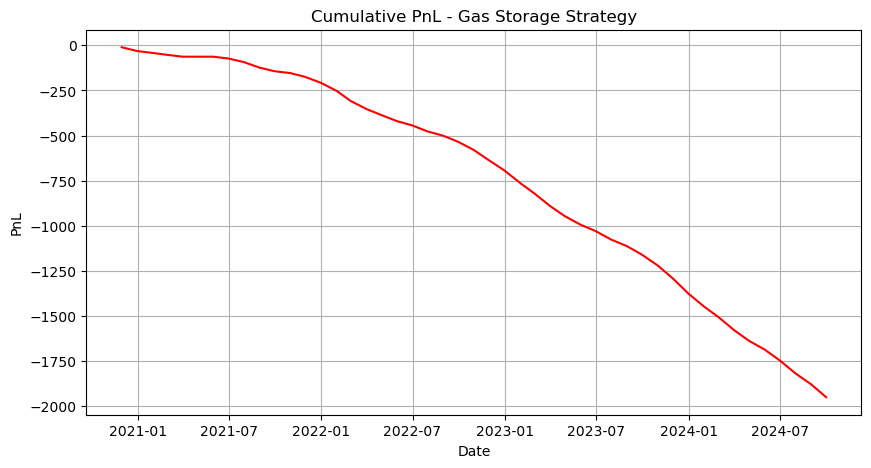


FINAL RESULTS
Final PnL: -1950.50
Final Storage Level: 6


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA (CSV)
# =========================
df = pd.read_csv("C:/Users/elisabethung/Downloads/Nat_Gas_Data.csv")

df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates")

dates = df["Dates"].values
prices = df["Prices"].values

# =========================
# 2. PLOT PRICE EVOLUTION
# =========================
plt.figure(figsize=(10,5))
plt.plot(df["Dates"], df["Prices"], label="Gas Price", color="blue")
plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.legend()
plt.show()

# =========================
# 3. SIMPLE STORAGE STRATEGY MODEL
# (Buy low, sell high approximation)
# =========================

cashflow = []
position = 0  # stored gas
cash = 0

storage_level = []

for i in range(1, len(prices)):

    # simple signal: price increase -> buy, decrease -> sell
    if prices[i] > prices[i-1]:
        cash -= prices[i]
        position += 1

    elif prices[i] < prices[i-1] and position > 0:
        cash += prices[i]
        position -= 1

    # track values
    cashflow.append(cash)
    storage_level.append(position)

# =========================
# 4. PLOT STORAGE LEVEL
# =========================
plt.figure(figsize=(10,5))
plt.plot(df["Dates"][1:], storage_level, color="green")
plt.title("Storage Level Over Time")
plt.xlabel("Date")
plt.ylabel("Volume Stored")
plt.grid()
plt.show()

# =========================
# 5. PLOT CUMULATIVE PNL
# =========================
plt.figure(figsize=(10,5))
plt.plot(df["Dates"][1:], np.cumsum(cashflow), color="red")
plt.title("Cumulative PnL - Gas Storage Strategy")
plt.xlabel("Date")
plt.ylabel("PnL")
plt.grid()
plt.show()

# =========================
# 6. FINAL OUTPUT
# =========================
final_pnl = np.sum(cashflow)

print("\n========================")
print("FINAL RESULTS")
print("========================")
print(f"Final PnL: {final_pnl:.2f}")
print(f"Final Storage Level: {position}")